In [117]:
import yfinance as yf
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import itertools
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.ar_model import AutoReg

In [118]:
energy_tickers = ['CVX', 'XOM', 'BKR', 'HAL', 'SLB', 'APA', 'COP', 'CTRA', 'DVN', 'FANG', 'EOG', 'EQT', 'EXE', 'OXY', 'TPL', 'MPC', 'PSX', 'VLO', 'KMI', 'OKE', 'TRGP', 'WMB']

def download_data(stock, start, end):
    try:
        df = yf.download(stock, start=start, end=end)
        return df['Close']
    except Exception as e:
        print(f"Error downloading {stock}: {e}")
        return None

data = download_data(energy_tickers, start='2022-01-01', end='2026-01-01')
data = data.dropna(axis=1)



[*********************100%***********************]  22 of 22 completed


In [119]:
def calculate_hurst_exponent(time_series, max_lag=20):
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(time_series[lag:], time_series[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

def calculate_half_life(spread):
    spread_lag = spread.shift(1).dropna()
    spread_ret = spread - spread_lag
    spread_ret = spread_ret.dropna()
    spread_lag = sm.add_constant(spread_lag)
    model = sm.OLS(spread_ret, spread_lag)
    res = model.fit()
    lam = res.params.iloc[1]
    if lam >= 0:
        return np.inf 
    return -np.log(2) / lam


total_pairs = 0
passed_corr = 0
passed_coint = 0
passed_hurst = 0
passed_halflife = 0

viable_pairs = []

for stock_a, stock_b in itertools.combinations(data.columns, 2):
    total_pairs += 1
    
    df = data[[stock_a, stock_b]].dropna()
    
    # Correlation Filter
    corr = df[stock_a].corr(df[stock_b])
    if corr < 0.70: continue
    passed_corr += 1
        
    # Cointegration 95% confidence filter
    score, p_value, _ = ts.coint(df[stock_a], df[stock_b])
    if p_value >= 0.05: continue
    passed_coint += 1
        
    # Calculate Spread
    X = sm.add_constant(df[stock_b])
    model = sm.OLS(df[stock_a], X).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]
    spread = df[stock_a] - (beta * df[stock_b])

    # Hurst Exponent Filter
    hurst = calculate_hurst_exponent(spread.values)
    if hurst >= 0.50: continue
    passed_hurst += 1
        
    # Half-Life Filter
    half_life = calculate_half_life(spread)
    if not (1 <= half_life <= 60): continue
    passed_halflife += 1
        
    viable_pairs.append(f"{stock_a} / {stock_b} (p-val: {p_value:.3f}, HL: {half_life:.1f})")

print(f"Total Combinations Tested: {total_pairs}")
print(f"Passed Correlation (>0.70):  {passed_corr}")
print(f"Passed Cointegration (<0.05):{passed_coint}")
print(f"Passed Hurst (<0.50):        {passed_hurst}")
print(f"Passed Half-Life (1-90d):    {passed_halflife}")

print(f"\nTotal Surviving Pairs: {len(viable_pairs)}")
for p in viable_pairs:
    print(p)

Total Combinations Tested: 231
Passed Correlation (>0.70):  47
Passed Cointegration (<0.05):4
Passed Hurst (<0.50):        4
Passed Half-Life (1-90d):    4

Total Surviving Pairs: 4
COP / SLB (p-val: 0.022, HL: 31.2)
EOG / FANG (p-val: 0.003, HL: 23.3)
EOG / XOM (p-val: 0.042, HL: 29.5)
MPC / PSX (p-val: 0.041, HL: 34.9)


The EOG / FANG pair has the lowest p-value from the surviving ones. Quick check - both are in the same subindustry (Oil and Gas Exploration and Production), so we can choose them as our trading pair.

[*********************100%***********************]  2 of 2 completed


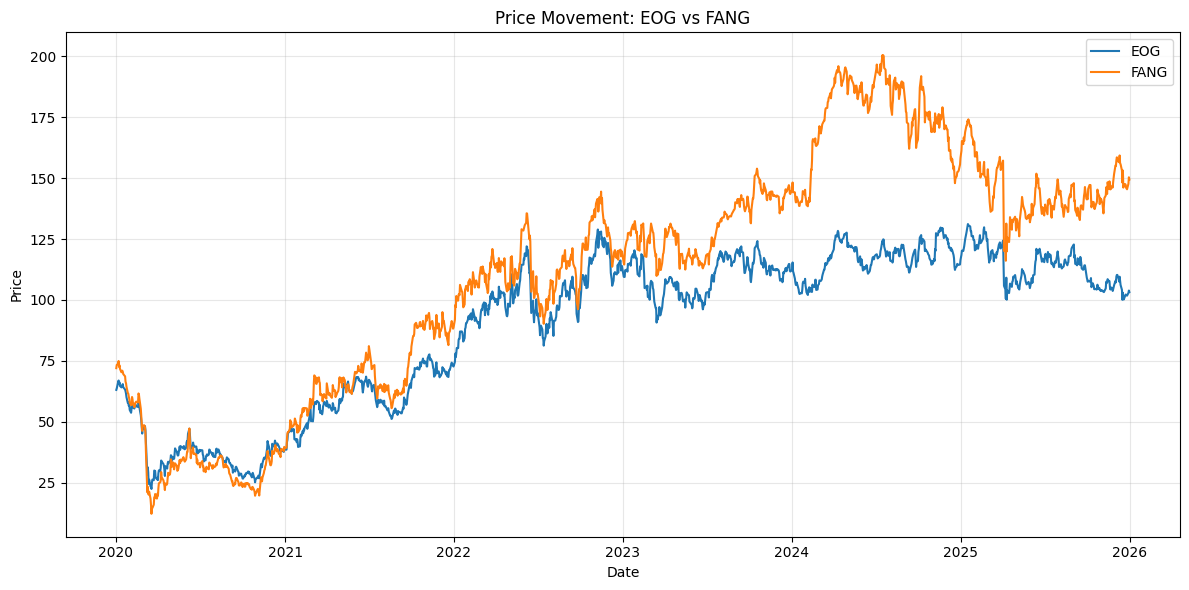

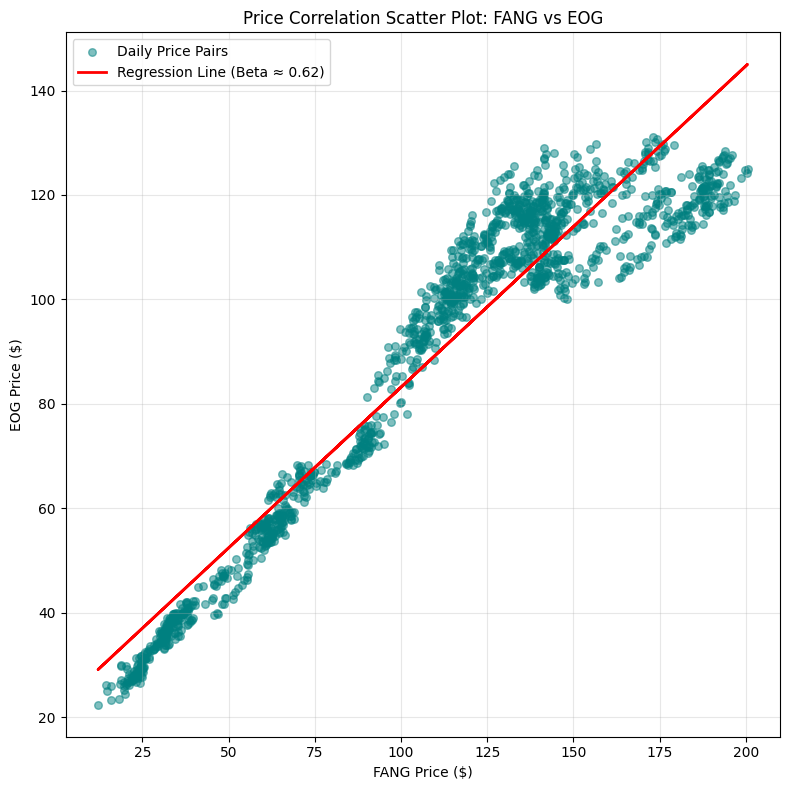

In [120]:
# Sanity checks

stock_a = 'EOG'  
stock_b = 'FANG' 

tickers = [stock_a, stock_b]

data = yf.download(tickers, start='2020-01-01', end='2026-01-01')['Close']
data = data.dropna()

plt.figure(figsize=(12, 6))
plt.plot(data.index, data[stock_a], label=stock_a, linewidth=1.5)
plt.plot(data.index, data[stock_b], label=stock_b, linewidth=1.5)

plt.title(f'Price Movement: {stock_a} vs {stock_b}')
plt.ylabel('Price')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))

plt.scatter(data[stock_b], data[stock_a], alpha=0.5, color='teal', s=30, label='Daily Price Pairs')

beta, alpha = np.polyfit(data[stock_b], data[stock_a], 1)
residuals = data[stock_a] - (beta * data[stock_b] + alpha)

# Plot the regression line
plt.plot(data[stock_b], beta * data[stock_b] + alpha, color='red', linewidth=2, label=f'Regression Line (Beta ≈ {beta:.2f})')

plt.title(f'Price Correlation Scatter Plot: {stock_b} vs {stock_a}')
plt.xlabel(f'{stock_b} Price ($)')
plt.ylabel(f'{stock_a} Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [121]:
# Data Generation

# least square solution for beta: log(A) = b*log(B) + mu
def estimate_beta_OU(A, B):
    a_log = np.log(A)
    b_log = np.log(B).values.reshape(-1, 1)
    
    model = LinearRegression().fit(b_log, a_log)

    return model.coef_[0]


# this method is generated with an LLM
def params_OU(data):
    res = AutoReg(data, lags=1).fit()

    alpha, rho = res.params  # [const, lag1]

    mu        = alpha / (1 - rho)
    theta     = -np.log(rho)
    sigma_eps = np.sqrt(res.sigma2)
    sigma     = sigma_eps * np.sqrt(2 * theta / (1 - np.exp(-2 * theta)))

    return mu, theta, sigma

def generate_OU(meanOU, thetaOU, sigmaOU, N=10000):
    ans = [1.0]
    for _ in range(N-1):
        ans.append(ans[-1]+thetaOU*(meanOU-ans[-1]) + sigmaOU * np.random.normal())
    return ans


[*********************100%***********************]  2 of 2 completed

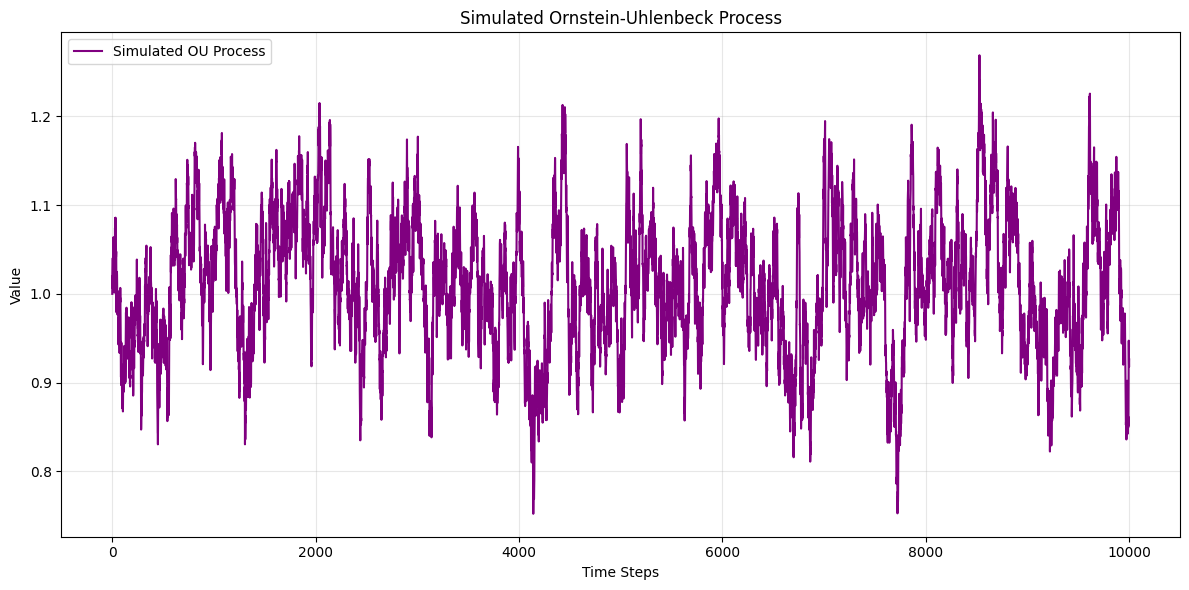

In [122]:
tickers = ['EOG', 'FANG']
df = yf.download(tickers, start='2020-01-01', end='2026-01-01')['Close']

df = df.dropna()
beta = estimate_beta_OU(df['EOG'], df['FANG'])

log_spread = np.log(df['EOG']) - (beta * np.log(df['FANG']))

meanOU, thetaOU, sigmaOU = params_OU(log_spread.values)
OU_path = generate_OU(meanOU, thetaOU, sigmaOU)

plt.figure(figsize=(12, 6))
plt.plot(OU_path, label='Simulated OU Process', color='purple')
plt.title('Simulated Ornstein-Uhlenbeck Process')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()